# diag_paris_rome — causal tracing of the 'Paris' fact

Replicates the **causal tracing** method of **Meng et al. (2022), "Locating and Editing Factual Associations in GPT" (ROME)** on **Llama-3.1-8B-Instruct**.

**Prompt:** `"Paris is the capital of"` → expected answer `" France"`.

**Method:** (1) clean run, cache every layer's residual state and record P(France). (2) Corrupt the **Paris** subject tokens with noise → P(France) collapses. (3) For every (layer, token position), re-run corrupted but **restore** that one clean state and measure how much P(France) recovers. The bright cells in the heatmap are where the Paris→France association is *stored*.

In [1]:
import torch, numpy as np, os
from transformers import AutoModelForCausalLM, AutoTokenizer
os.makedirs("plots", exist_ok=True)

MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"   # same Instruct model used in the steering experiments
device = torch.device("mps" if torch.backends.mps.is_available()
                      else ("cuda" if torch.cuda.is_available() else "cpu"))
dtype  = torch.float16 if device.type != "cpu" else torch.float32
print("device:", device, "| dtype:", dtype)

tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, torch_dtype=dtype).to(device).eval()
NL = model.config.num_hidden_layers
D  = model.config.hidden_size
print("layers:", NL, "| d_model:", D)

device: mps | dtype: torch.float16


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

layers: 32 | d_model: 4096


## 1. Prompt, answer token, and subject positions

In [2]:
PROMPT = "Paris is the capital of"     # raw completion prompt (no chat template)
ANSWER = " France"
SUBJECT = "Paris"

ids = tok(PROMPT, return_tensors="pt").to(device)
toks = ids.input_ids[0]
tok_strs = [tok.decode([t]) for t in toks]
print("tokens:", tok_strs)
ans_id = tok(ANSWER, add_special_tokens=False).input_ids[0]
print("answer token:", repr(tok.decode([ans_id])), "id", ans_id)

# locate subject token positions (contiguous match of SUBJECT tokens)
subj_ids = tok(SUBJECT, add_special_tokens=False).input_ids
tl = toks.tolist(); subj_pos = None
for s in range(len(tl)-len(subj_ids)+1):
    if tl[s:s+len(subj_ids)] == subj_ids:
        subj_pos = list(range(s, s+len(subj_ids))); break
if subj_pos is None: subj_pos = [1]   # fallback: first token after BOS
print("subject positions:", subj_pos, "->", [tok_strs[p] for p in subj_pos])

tokens: ['<|begin_of_text|>', 'Paris', ' is', ' the', ' capital', ' of']
answer token: ' France' id 9822
subject positions: [1] -> ['Paris']


## 2. Clean run — cache residual states, record P(France)

In [3]:
layers = model.model.layers
clean_cache = {}
def _save(idx):
    def f(m, i, o): clean_cache[idx] = (o[0] if isinstance(o, tuple) else o).detach().clone()
    return f

@torch.no_grad()
def run_clean():
    hs = [layers[i].register_forward_hook(_save(i)) for i in range(NL)]
    out = model(**ids)
    for h in hs: h.remove()
    return torch.softmax(out.logits[0, -1], -1)[ans_id].item()

clean_p = run_clean()
print(f"clean P(France) = {clean_p:.4f}")

clean P(France) = 0.8921


## 3. Corruption + single-state restoration hooks

In [4]:
with torch.no_grad():
    emb_std = model.model.embed_tokens.weight.float().std().item()
NOISE = 3.0 * emb_std     # ROME uses ~3x embedding std
emb = model.model.embed_tokens

def corrupt_hook(noise_vec):
    def f(m, i, o):
        o = o.clone()
        for k, p in enumerate(subj_pos): o[0, p, :] += noise_vec[k].to(o.dtype)
        return o
    return f

def restore_hook(layer_idx, pos):
    def f(m, i, o):
        o0 = o[0] if isinstance(o, tuple) else o
        o0 = o0.clone(); o0[0, pos, :] = clean_cache[layer_idx][0, pos, :].to(o0.dtype)
        return (o0,) + tuple(o[1:]) if isinstance(o, tuple) else o0
    return f

@torch.no_grad()
def run_corrupted(noise_vec, restore=None):
    handles = [emb.register_forward_hook(corrupt_hook(noise_vec))]
    if restore is not None:
        l, t = restore; handles.append(layers[l].register_forward_hook(restore_hook(l, t)))
    out = model(**ids)
    for h in handles: h.remove()
    return torch.softmax(out.logits[0, -1], -1)[ans_id].item()

## 4. Causal trace (avg over noise samples) — the main loop
`N_NOISE=10` is the default; reduce to 5 if MPS is slow. Total forward passes ≈ NL × n_tokens × N_NOISE.

In [5]:
N_NOISE = 10
T = len(toks)
rng = np.random.default_rng(0)
noises = [torch.tensor(rng.standard_normal((len(subj_pos), D)) * NOISE, dtype=dtype, device=device)
          for _ in range(N_NOISE)]

corrupt_p = float(np.mean([run_corrupted(nz) for nz in noises]))
print(f"corrupted P(France) = {corrupt_p:.4f}  (clean was {clean_p:.4f})")

grid = np.zeros((NL, T))
for l in range(NL):
    for t in range(T):
        grid[l, t] = np.mean([run_corrupted(nz, restore=(l, t)) for nz in noises])
    print(f"layer {l+1}/{NL} done", end="\r")
print("\ndone.")

corrupted P(France) = 0.0209  (clean was 0.8921)
layer 32/32 done
done.


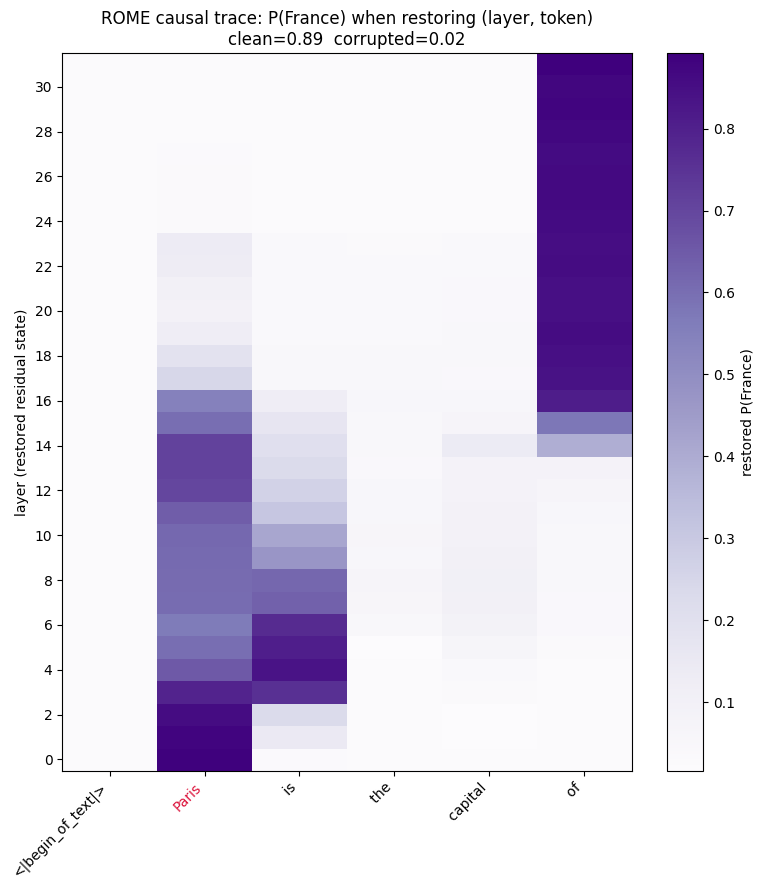

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(grid, aspect="auto", origin="lower", cmap="Purples")
ax.set_yticks(range(0, NL, 2)); ax.set_ylabel("layer (restored residual state)")
ax.set_xticks(range(T)); ax.set_xticklabels(tok_strs, rotation=45, ha="right")
for p in subj_pos: ax.get_xticklabels()[p].set_color("crimson")
ax.set_title(f"ROME causal trace: P(France) when restoring (layer, token)\nclean={clean_p:.2f}  corrupted={corrupt_p:.2f}")
plt.colorbar(im, label="restored P(France)")
plt.tight_layout(); plt.savefig("plots/diag_paris_rome_trace.png", dpi=120); plt.show()

## Reading this
- Bright cells = restoring *that* state alone rescues the fact → that's where Paris→France lives.
- ROME's canonical result: a strong **early-to-mid layer** site at the **last subject token** (‘Paris’, shown in red), plus a late site at the final token. If you see the early-mid subject-token band, the *factual* Paris is stored there — compare against where RFM steering injects (mid layers 9/17) and where it fails to surface Paris.